## Imports

In [1]:
import re
from collections import defaultdict

import numpy as np
import pandas as pd
from lemminflect import getAllLemmas, getAllLemmasOOV
from nltk import pos_tag, word_tokenize
from num2words import num2words as _num2words
from scipy.interpolate import make_interp_spline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from tqdm.notebook import tqdm

from analysis_helpers import Episode, Participant, show_content_warning
from analysis_helpers.constants import (
    CV_PARAMS,
    ENDFRAME_TIMES,
    EPISODE_WINDOW_SIZE,
    LDA_PARAMS,
    LEMMATIZER_EXCLUSIONS,
    POS_MAPPING,
    PROCESSED_DIR,
    RECALL_WINDOW_SIZE,
    STOP_WORDS,
    TEXT_SUBSTITUTIONS
)

In [2]:
show_content_warning()

⚠️ The episodes of [*Atlanta*](https://en.wikipedia.org/wiki/Atlanta_(TV_series)) viewed by participants in this study explore themes of racism, homophobia, and other forms of discrimination. As a result, certain files in this repository&mdash;possibly including this one&mdash;contain references to language that may be offensive or harmful. This language appears only in service of accurately representing and analyzing the stimuli and participants' responses, and its inclusion does not reflect an endorsement of its use by the authors.

## Functions

In [3]:
def num2words(number: str) -> str:
    # loose heuristic for identifying years
    if len(number) == 4 and 1900 < int(number) < 2025:
        return _num2words(number, to='year')
    return _num2words(number, to='cardinal')

In [4]:
def lemmatize(word: str, treebank_tag: str) -> str:
    if (
            treebank_tag in LEMMATIZER_EXCLUSIONS['treebank_tags']
            or word.lower() in LEMMATIZER_EXCLUSIONS['words']
            or '_' in word    # n-grams from TEXT_SUBSTITUTIONS
            or '~' in word    # censored profanity
    ):
        return word
    
    universal_tag = POS_MAPPING.get(treebank_tag)
    # returns a dict of {POS: (lemmas, ...), ...}
    lemma_candidates = getAllLemmas(word, universal_tag)

    if len(lemma_candidates) == 0:
        # no lemmas found via dictionary lookup.
        # Word may not be lemmatizeable, or may have been mis-tagged
        # because sentence fragments in annotations & 
        # stream-of-consciousness in recall transcripts both confuse the 
        # POS tagger. Try re-tagging first.
        new_treebank_tag = pos_tag([word])[0][1]
        if new_treebank_tag != treebank_tag:
            return lemmatize(word, new_treebank_tag)
        
        # If we have a POS tag, also try rule-based lemmatization
        if universal_tag is not None:
            # returns a 1-item dict of {POS: (lemma,)}, or an empty dict
            lemma_candidates_oov = getAllLemmasOOV(word, universal_tag)
            if len(lemma_candidates_oov) == 0:
                return word
            
            lemma_oov = lemma_candidates_oov[universal_tag][0]
            if lemma_oov != word:
                if lemma_oov.endswith('z') and word[word.rindex('z') + 1] == 'e':
                    # when inflections of -ze verbs (e.g., "recognized", 
                    # "realizes", etc.) are mis-tagged as different POS, 
                    # rule-based lemmatizer removes trailing "e"
                    lemma_oov = f'{lemma_oov}e'

            return lemma_oov
        return word
    
    if len(lemma_candidates) > 1:
        # universal_tag is None and word has lemmas for multiple POS
        if any(len(pos_lemmas) > 1 for pos_lemmas in lemma_candidates.values()):
            # word has >1 possible lemma for at least 1 POS
            raise RuntimeError(
                f'Multiple potential lemmas found for "{word}" ({treebank_tag}'
                f' -> {universal_tag}):\n\t{lemma_candidates=}'
            )
        
        unique_lemmas = tuple(set(
            pos_lemmas[0] for pos_lemmas in lemma_candidates.values()
        ))
        if len(unique_lemmas) > 1:
            # word has different possible lemmas for different POS.
            # Default to choosing the shortest one.
            if any(len(lem) == len(unique_lemmas[0]) for lem in unique_lemmas[1:]):
                # no single shortest option to choose
                raise RuntimeError(
                    f'Multiple potential lemmas found for "{word}" '
                    f'({treebank_tag} -> {universal_tag}):\n\t{lemma_candidates=}'
                )
            return min(unique_lemmas, key=len)
        return unique_lemmas[0]
    
    # Note: checked all instances in episode annotations where >1 lemma 
    # found for given word/POS, and 1st option is always the "right" one
    return tuple(lemma_candidates.values())[0][0]

In [5]:
def preprocess_text(text: str) -> str:
    # combine n-grams, standardize names, replace euphemisms, etc. 
    # before tokenizing/lemmatizing
    for pattern, replacement in TEXT_SUBSTITUTIONS.items():
        text = pattern.sub(replacement, text)
    
    # convert digits to word form
    text = re.sub(r'(\d+)', lambda match: num2words(match.group(0)), text)
    
    # temporarily replace asterisks in censored expletives with tildes 
    # so the tokenizer doesn't split on them
    text = text.replace('*', '~')
    
    # tokenize, POS tag, lemmatize
    lemmas = []
    for token, tag in pos_tag(word_tokenize(text)):
        if token.lower() not in STOP_WORDS:
            lemmas.append(lemmatize(token, tag))
    
    text = ' '.join(lemmas).replace('~', '*')
    
    # normalize case, remove all punctuation except _ and *
    text = re.sub(r"[.,!?:;/'`()[\]-]+", ' ', text).lower()
    
    # normalize whitespace, remove any additional stop-words introduced 
    # by lemmatization/punctuation removal
    return ' '.join(token for token in text.split() if token not in STOP_WORDS)

In [6]:
def parse_windows(textlist: list[str], wsize: int) -> list[str]:
    windows = []
    for ix in range(1, wsize):
        windows.append(' '.join(textlist[: ix]))
    
    for ix in range(len(textlist)):
        windows.append(' '.join(textlist[ix : ix + wsize]))
    
    return windows

In [7]:
def get_midpoint_times(
        onset_times: list[float], 
        wsize: int, 
        endframe_time: float
) -> list[float]:
    midpoint_times = []
    for ix in range(1, wsize):
        midpoint_times.append(onset_times[ix] / 2)
        
    for ix in range(len(onset_times) - wsize):
        midpoint_times.append((onset_times[ix] + onset_times[ix + wsize]) / 2)
        
    for ix in range(len(onset_times) - wsize, len(onset_times)):
        midpoint_times.append((onset_times[ix] + endframe_time) / 2)

    return midpoint_times

In [8]:
def scale_recall_timeseries(
        rec_windows: list[str], 
        wsize: float, 
        episode_tmax: float
) -> np.ndarray:
    tvals = [0]
    next_tval = 0
    for window in rec_windows[1:]:
        delta_t = len(window.split()) / wsize
        next_tval += delta_t
        tvals.append(next_tval)
    
    return np.array(tvals) * int(episode_tmax) / tvals[-1]

In [9]:
def resample_trajectory(
        trajectory: np.ndarray, 
        timestamps: list[float], 
        new_tmax: float, 
        resolution: int = 1
) -> np.ndarray[float]:
    new_timepoints = np.arange(int(new_tmax) + resolution, step=resolution)
    spline = make_interp_spline(timestamps, trajectory, k=1, axis=0)
    return spline(new_timepoints, extrapolate=True)

## Load data

In [10]:
atlep1 = Episode('atlep1')
atlep2 = Episode('atlep2')
arrdev = Episode('arrdev')

participants = Participant.load_all()
avg_participant = Participant('average')

## Transform episodes

In [11]:
for episode in (atlep1, atlep2, arrdev):
    processed_annotations = (
        episode.annotations
        # drop frame, onset time, & (manually labeled) scene name cols
        .loc[:, 'Narrative details (external events)':'Setting']
        # concatenate all annotated features for each shot. Adding 
        # period as delimiter helps POS tagger
        .apply(lambda row: '. '.join(row.dropna()), axis=1)
        # remove period delimiter if annotation text already ended with 
        # punctuation
        .str.replace(r'(?<=\W)\. ', ' ', regex=True)
        # remove single quotes (used for nested quotes in "Speech" 
        # column). Leave apostrophes used in plural possessives (Xs') & 
        # shortened gerunds (Xin') to be handled separately.
        .str.replace(r"(?<=\W)'|(?<!s)(?<!in)'(?=\W)", '', regex=True)
        # run preprocessing
        .apply(preprocess_text)
        .tolist()
    )
    
    # parse annotations into overlapping sliding windows
    episode.windows = parse_windows(processed_annotations, wsize=EPISODE_WINDOW_SIZE)
    
    # vectorize windows to token counts
    episode.fit_cv = CountVectorizer(**CV_PARAMS).fit(episode.windows)
    window_wordcounts = episode.fit_cv.transform(episode.windows)
    
    # fit topic model to sliding windows and transform
    episode.fit_lda = LatentDirichletAllocation(**LDA_PARAMS).fit(window_wordcounts)
    window_trajectory = episode.fit_lda.transform(window_wordcounts)
    
    # resample trajectory to 1 sample per second of video
    midpoint_times = get_midpoint_times(episode.annotations['Onset time'].tolist(), 
                                        wsize=EPISODE_WINDOW_SIZE, 
                                        endframe_time=episode.endframe_time)
    episode.trajectory = resample_trajectory(window_trajectory, 
                                             timestamps=midpoint_times, 
                                             new_tmax=episode.endframe_time)

In [98]:
def get_top_words(cv, lda, n_words=10):
    topic_words = {}
    vocab = cv.get_feature_names_out()
    for topic, component in enumerate(lda.components_):
        word_ix = np.argsort(component)[::-1][:n_words]
        topic_words[topic] = [vocab[i] for i in word_ix]
    return topic_words

## Transform recalls

In [60]:
pbar = tqdm(total=len(participants) * 3, leave=False)
for rectype, episode in zip(('atlep1', 'delayed', 'atlep2', 'arrdev'), 
                            (atlep1, atlep1, atlep2, arrdev)):
    rectype_trajs = []
    for p in participants:
        pbar.set_description(f'{rectype}, P{p.sub_n}')
        if (
                (rectype == 'atlep2' and p.condition == 'B') 
                or (rectype == 'arrdev' and p.condition == 'A')
        ):
            continue
        
        processed_transcript = preprocess_text(p.transcripts[rectype])
        p.windows[rectype] = parse_windows(processed_transcript.split(), 
                                           wsize=RECALL_WINDOW_SIZE)
        
        window_wordcounts = episode.fit_cv.transform(p.windows[rectype])
        window_trajectory = episode.fit_lda.transform(window_wordcounts)
        
        window_tpts = scale_recall_timeseries(p.windows[rectype], 
                                              wsize=RECALL_WINDOW_SIZE, 
                                              episode_tmax=episode.endframe_time)
        p.trajectories[rectype] = resample_trajectory(window_trajectory, 
                                                      timestamps=window_tpts, 
                                                      new_tmax=episode.endframe_time)
        rectype_trajs.append(p.trajectories[rectype])
        pbar.update()
        
    avg_participant.trajectories[rectype] = np.mean(rectype_trajs, axis=0)
        
pbar.close()

  0%|          | 0/171 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

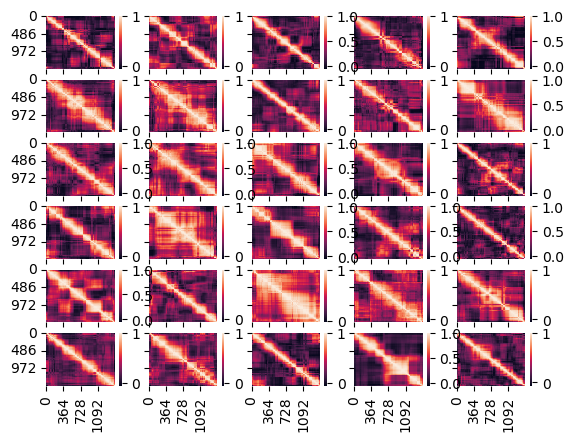

In [97]:
fig, axes = plt.subplots(6, 5, sharex=True, sharey=True)

for p, ax in zip(tqdm(participants[:30], leave=False), axes.ravel()):
    sns.heatmap(np.corrcoef(p.trajectories['atlep1']), ax=ax)
plt.show()

In [20]:
import hypertools as hyp
import matplotlib.pyplot as plt
%matplotlib inline

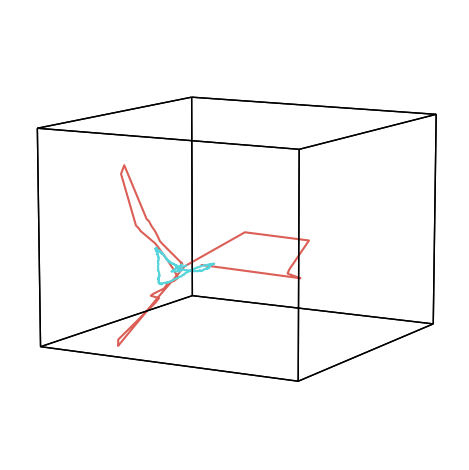

In [63]:
hyp.plot([atlep1.trajectory, avg_participant.trajectories['atlep1']])#, fmt=' ', marker='.')

In [54]:
import seaborn as sns

<Axes: >

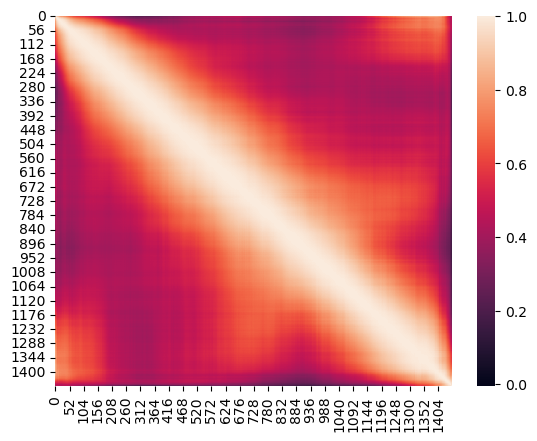

In [91]:
sns.heatmap(np.corrcoef(avg_participant.trajectories['atlep1']))

<Axes: >

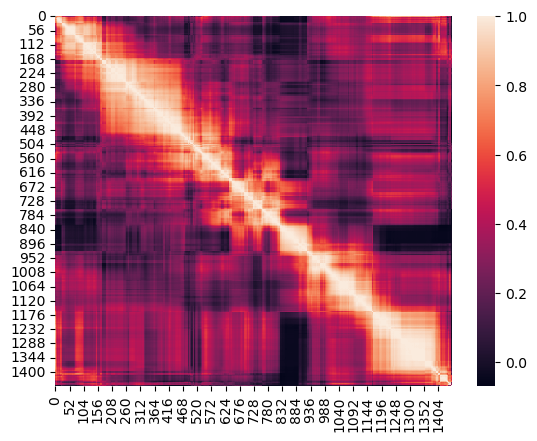

In [101]:
sns.heatmap(np.corrcoef(participants[8].trajectories['atlep1']))

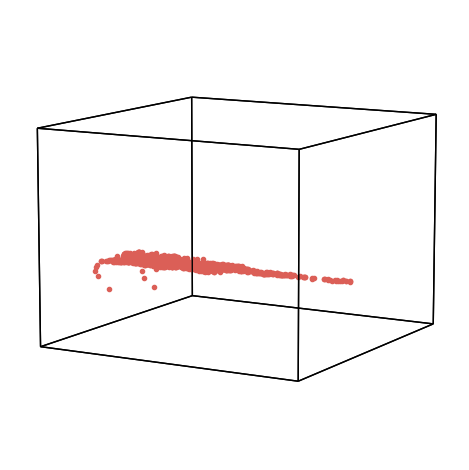

In [46]:
hyp.plot(avg_participant.trajectories['atlep1'][1:-1], fmt=' ', marker='.')

In [132]:
import hypertools as hyp
import matplotlib.pyplot as plt
%matplotlib inline

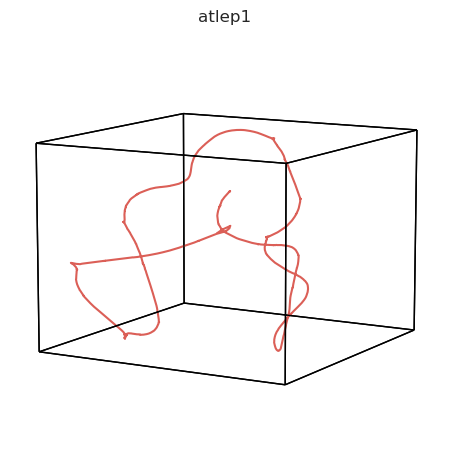

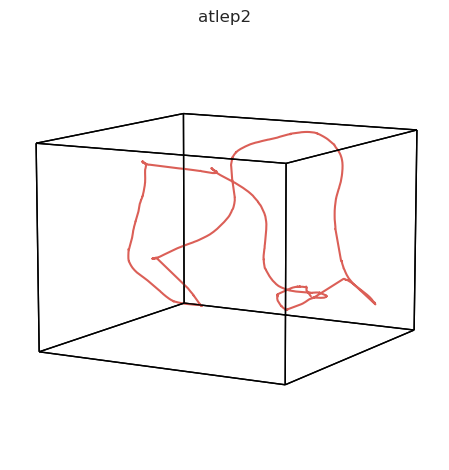

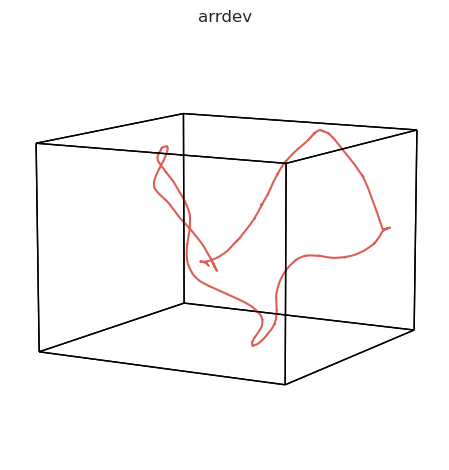

In [140]:
for episode in (atlep1, atlep2, arrdev):
    hyp.plot(episode.trajectory, title=episode.name, reduce='UMAP')
    plt.show()

In [305]:
def find_ntopics(episode, max_topics=50, var_tol=1e-10, pbar=False):
    if hasattr(episode, 'windows'):
        windows = episode.windows
    else:
        processed_annotations = (
            episode.annotations
            .loc[:, 'Narrative details (external events)':'Setting']
            .apply(lambda row: '. '.join(row.dropna()), axis=1)
            .str.replace(r'(?<=\W)\. ', ' ', regex=True)
            .str.replace(r"(?<=\W)'|(?<!s)(?<!in)'(?=\W)", '', regex=True)
            .apply(preprocess_text)
            .tolist()
        )
        windows = parse_windows(processed_annotations, wsize=EPISODE_WINDOW_SIZE)
        
    fit_cv = CountVectorizer(**CV_PARAMS).fit(windows)
    window_wordcounts = fit_cv.transform(windows)

    tmp_lda_params = LDA_PARAMS.copy()
    print(f'Optimizing {episode.name}')
    
    for n_topics in range(max_topics, 0, -1):
        tmp_lda_params['n_components'] = n_topics
        fit_lda = LatentDirichletAllocation(**tmp_lda_params).fit(window_wordcounts)
        window_trajectory = fit_lda.transform(window_wordcounts)
        n_used = sum(fit_lda.components_.var(axis=1) > var_tol)
#         n_used_alt = sum(window_trajectory.var(axis=0) > var_tol)
#         if n_used_alt != n_used:
#             print(f'DISAGREEMENT: {n_used=}, {n_used_alt=}')
        print(f'\t{n_topics} topics: {n_used} used')

#         plt.figure(figsize=(8, 4))
#         sns.histplot(window_trajectory.var(axis=0), log_scale=True, bins=50)
#         plt.xlim(1e-9, 1)
#         plt.ylim(0, 40)
#         plt.title(f"{n_topics} topics: {n_used} used")
#         plt.show()
        if n_used == n_topics:
            print('finished')
            break

In [306]:
find_ntopics(atlep1)

Optimizing atlep1
	50 topics: 19 used
	49 topics: 20 used
	48 topics: 17 used
	47 topics: 17 used
	46 topics: 18 used
	45 topics: 20 used
	44 topics: 18 used
	43 topics: 17 used
	42 topics: 17 used
	41 topics: 17 used
	40 topics: 16 used
	39 topics: 16 used
	38 topics: 14 used
	37 topics: 13 used
	36 topics: 15 used
	35 topics: 17 used
	34 topics: 16 used
	33 topics: 16 used
	32 topics: 16 used
	31 topics: 15 used
	30 topics: 14 used
	29 topics: 13 used
	28 topics: 13 used
	27 topics: 14 used
	26 topics: 14 used
	25 topics: 13 used
	24 topics: 13 used
	23 topics: 12 used
	22 topics: 11 used
DISAGREEMENT: n_used=np.int64(9), n_used_alt=np.int64(10)
	21 topics: 9 used
	20 topics: 12 used
	19 topics: 11 used
	18 topics: 11 used
	17 topics: 9 used
	16 topics: 12 used
	15 topics: 10 used
	14 topics: 10 used
	13 topics: 10 used
	12 topics: 10 used
	11 topics: 10 used
	10 topics: 9 used
	9 topics: 9 used
finished


In [104]:
# find_ntopics(atlep2)

In [249]:
tmp_lda_params = LDA_PARAMS.copy()
tmp_lda_params['n_components'] = 50

In [493]:
# N_TOPICS = 21 # <- GIVES GOOD CORRMAT HEATMAP -- FLASHBACK MATCHES BEGINNING,
                # 2 SCENES WHERE DAVE TELLS STORY ALSO MATCH WEAKLY (AS THEY SHOULD)

N_TOPICS = 50
tmp_lda_params = LDA_PARAMS.copy()
tmp_lda_params['n_components'] = N_TOPICS
window_wordcounts = atlep1.fit_cv.transform(atlep1.windows)
fit_lda = LatentDirichletAllocation(topic_word_prior=0.6, doc_topic_prior=0.6, **tmp_lda_params).fit(window_wordcounts)
trajectory = fit_lda.transform(window_wordcounts)

In [494]:
sum(fit_lda.components_.var(1) > 1e-6)

np.int64(50)

In [495]:
fit_lda.components_.var(1)

array([7.97072405e-05, 7.97066910e-05, 7.97065947e-05, 7.97069203e-05,
       2.35481463e+04, 7.97065568e-05, 7.97074218e-05, 7.97067079e-05,
       2.72817643e+04, 7.97066643e-05, 3.62197857e+04, 7.97071087e-05,
       7.97065266e-05, 7.97085916e-05, 7.97066966e-05, 7.97065838e-05,
       2.07984098e+04, 7.97065110e-05, 7.97064466e-05, 7.97064883e-05,
       7.97065095e-05, 7.97065503e-05, 9.19335562e+04, 7.97067855e-05,
       3.57992366e+04, 7.97097221e-05, 7.97073075e-05, 2.36078374e+04,
       4.59034852e+04, 2.50685385e+04, 7.97082313e-05, 7.97067371e-05,
       7.97065237e-05, 7.97065587e-05, 4.81974979e+04, 4.43720644e+04,
       1.40738326e+04, 5.21099026e+04, 2.08009906e+04, 7.97066260e-05,
       2.21923492e+04, 7.97066285e-05, 7.97094990e-05, 4.54572865e+03,
       7.97066595e-05, 7.97065482e-05, 7.97065796e-05, 7.97139332e-05,
       7.97066725e-05, 7.97073518e-05])

In [502]:
sum(trajectory[123].round(5) == round(6.59909953e-04, 5))

np.int64(34)

In [106]:
sns.heatmap(np.corrcoef(trajectory))
plt.title(f'Atlep1, {trajectory.shape[1]} topics')
plt.show()

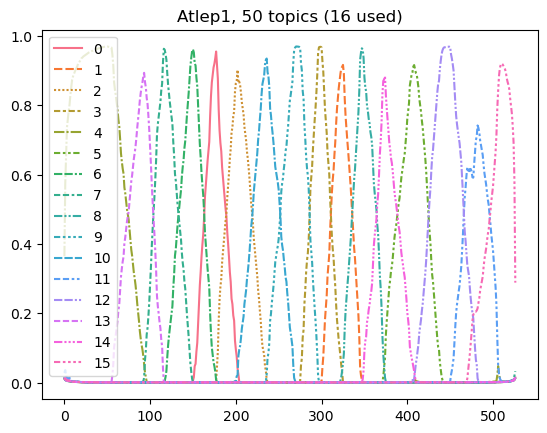

In [506]:
sns.lineplot(trajectory[:, trajectory.var(0) > 7e-4])
plt.title(f'Atlep1, {trajectory.shape[1]} topics ({sum(fit_lda.components_.var(1) > 7e-4)} used)')
plt.show()

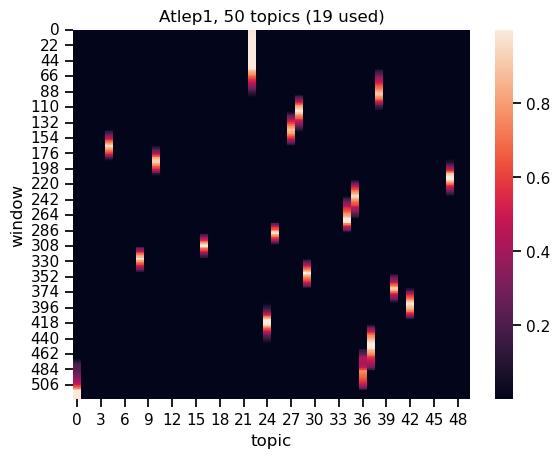

In [448]:
with sns.plotting_context('notebook'):
    sns.heatmap(trajectory)
    plt.xlabel('topic')
    plt.ylabel('window')
    plt.title(f'Atlep1, {trajectory.shape[1]} topics (19 used)')
    plt.show()

In [440]:
# N_TOPICS = 21 # <- GIVES GOOD CORRMAT HEATMAP -- FLASHBACK MATCHES BEGINNING,
                # 2 SCENES WHERE DAVE TELLS STORY ALSO MATCH WEAKLY (AS THEY SHOULD)

N_TOPICS = 50
tmp_lda_params = LDA_PARAMS.copy()
tmp_lda_params['n_components'] = N_TOPICS
window_wordcounts = atlep1.fit_cv.transform(atlep1.windows)
fit_lda = LatentDirichletAllocation(**tmp_lda_params).fit(window_wordcounts)
trajectory = fit_lda.transform(window_wordcounts)

In [441]:
sum(fit_lda.components_.var(1) > 1e-6)

np.int64(19)

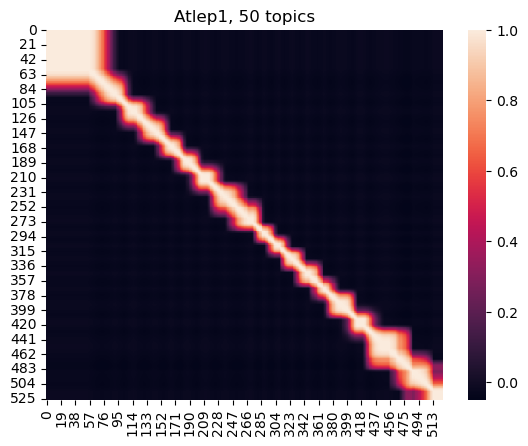

In [442]:
sns.heatmap(np.corrcoef(trajectory))
plt.title(f'Atlep1, {trajectory.shape[1]} topics')
plt.show()

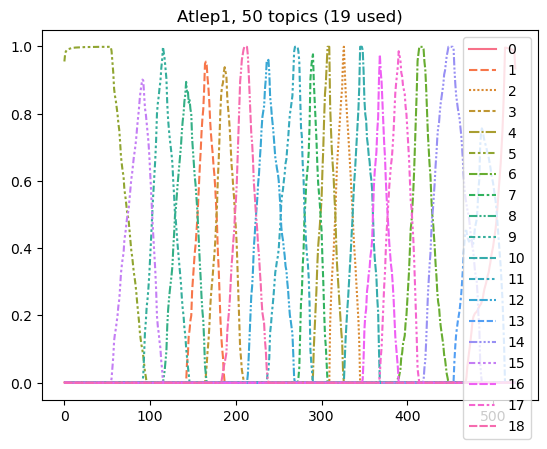

In [443]:
sns.lineplot(trajectory[:, trajectory.var(0) > 1e-7])
plt.title(f'Atlep1, {trajectory.shape[1]} topics (19 used)')
plt.show()

In [400]:
pearsonr(atlep1.trajectory[150], atlep1.trajectory[650])

PearsonRResult(statistic=np.float64(-0.01731814899834159), pvalue=np.float64(0.8642104151060426))

In [411]:
ix1, ix2 = 560, 570
print(f'full:  {pearsonr(atlep1.trajectory[ix1], atlep1.trajectory[ix2])}')
print(f'active: {pearsonr(atlep1.trajectory[ix1, atlep1.trajectory.var(0) > 1e-6], 
atlep1.trajectory[ix2, atlep1.trajectory.var(0) > 1e-6])}')



full:  PearsonRResult(statistic=np.float64(0.9006856566055871), pvalue=np.float64(2.9500705530103716e-37))
active: PearsonRResult(statistic=np.float64(0.8952346284459266), pvalue=np.float64(3.5169335510334832e-09))


In [399]:
atlep1.trajectory[650]

array([9.04424244e-06, 9.04424244e-06, 9.04424244e-06, 9.04424244e-06,
       9.04424244e-06, 9.04424244e-06, 9.04424244e-06, 9.04424244e-06,
       9.04424244e-06, 9.04424244e-06, 9.04424244e-06, 9.04424244e-06,
       9.04424244e-06, 9.04424244e-06, 9.04424244e-06, 9.04424244e-06,
       9.04424244e-06, 9.04424244e-06, 9.04424244e-06, 9.04424244e-06,
       9.04424244e-06, 9.04424244e-06, 9.04424244e-06, 9.04424244e-06,
       9.04424244e-06, 9.04424244e-06, 9.04424244e-06, 9.04424244e-06,
       9.04424244e-06, 9.04424244e-06, 9.04424244e-06, 9.04424244e-06,
       9.04424244e-06, 9.04424244e-06, 3.82045400e-01, 6.17068264e-01,
       9.04424244e-06, 9.04424244e-06, 9.04424244e-06, 9.04424244e-06,
       9.04424244e-06, 9.04424244e-06, 9.04424244e-06, 9.04424244e-06,
       9.04424244e-06, 9.04424244e-06, 9.04424244e-06, 9.04424244e-06,
       9.04424244e-06, 9.04424244e-06, 9.04424244e-06, 9.04424244e-06,
       9.04424244e-06, 9.04424244e-06, 9.04424244e-06, 9.04424244e-06,
      

<Axes: >

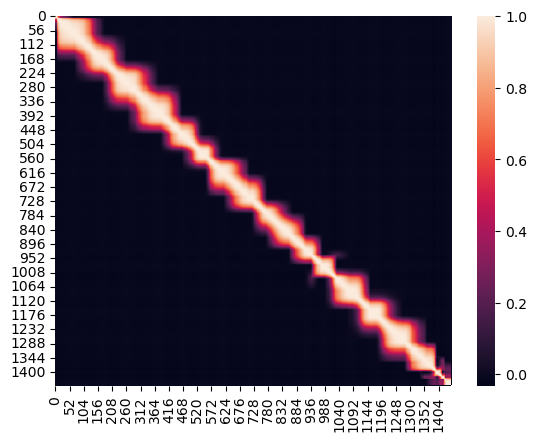

In [508]:
sns.heatmap(np.corrcoef(atlep1.trajectory))

<Axes: >

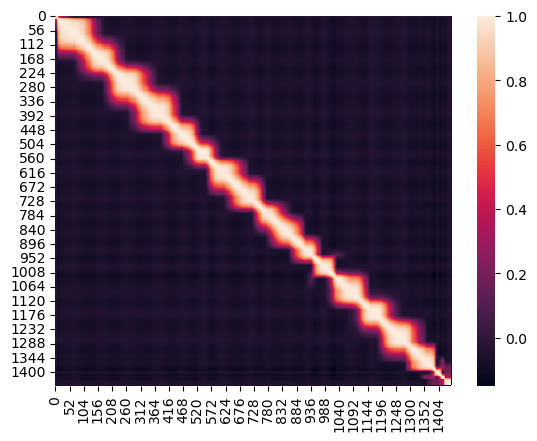

In [367]:
sns.heatmap(np.corrcoef(atlep1.trajectory[:, atlep1.fit_lda.components_.var(1) > 1e-4]))

In [107]:
# list(np.argsort(np.corrcoef(atlep1.trajectory)[0])[::-1])

<Axes: ylabel='Density'>

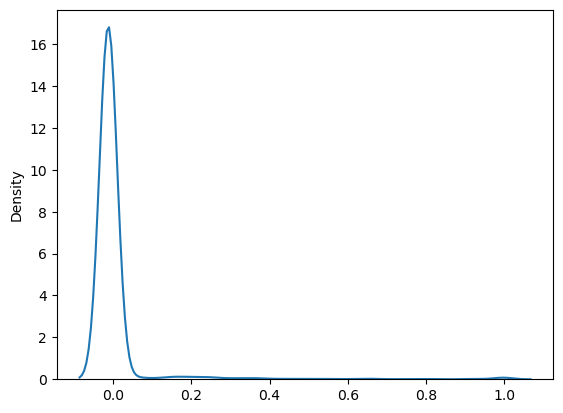

In [358]:
sns.kdeplot(np.corrcoef(atlep1.trajectory)[0])

In [355]:
np.corrcoef(atlep1.trajectory)[0, 1165]

np.float64(-0.01010101010101007)

<Axes: >

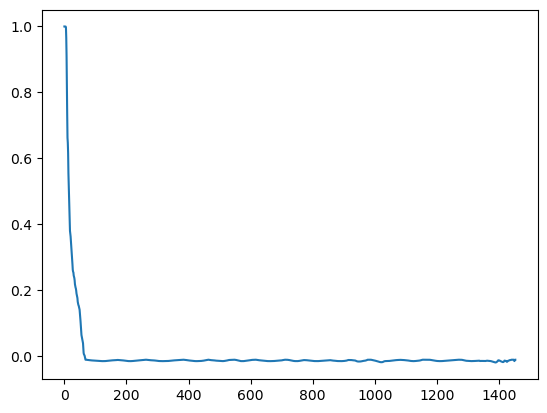

In [350]:
sns.lineplot(np.corrcoef(atlep1.trajectory)[0])

In [333]:
fit_lda.components_.var(1)

array([1.12626764e+04, 5.07066486e-35, 5.07066486e-35, 6.29236480e+04,
       5.52388024e-01, 7.98842509e+04, 5.07066486e-35, 5.07066486e-35,
       2.21220063e+05, 5.07066486e-35, 1.10815212e+05, 6.40923914e+04,
       5.07066486e-35, 3.08018617e+05, 5.07066486e-35, 4.01304596e+04,
       1.14768957e+05, 5.07066486e-35, 5.07066486e-35, 5.07066486e-35,
       5.07066486e-35])

In [330]:
trajectory.var(0)

array([6.34700564e-02, 3.37372781e-08, 3.37372781e-08, 5.12207346e-02,
       7.55096374e-07, 5.30552649e-02, 3.37372781e-08, 3.37372781e-08,
       7.51582642e-02, 3.37372781e-08, 7.71395596e-02, 4.57742915e-02,
       3.37372781e-08, 1.27253610e-01, 3.37372781e-08, 4.87595556e-02,
       6.73844074e-02, 3.37372781e-08, 3.37372781e-08, 3.37372781e-08,
       3.37372781e-08])

In [328]:
np.where(fit_lda.components_.var(1) > 1e-6)[0]

array([ 0,  3,  4,  5,  8, 10, 11, 13, 15, 16])

In [329]:
np.where(trajectory.var(0) > 1e-6)[0]

array([ 0,  3,  5,  8, 10, 11, 13, 15, 16])

In [308]:
sum(fit_lda.components_.var(axis=1) > 1e-5)

np.int64(13)

In [304]:
fit_lda.components_.var(axis=1)

array([2.10353183e+03, 1.20370622e-35, 1.20370622e-35, 1.20370622e-35,
       4.41808088e+02, 1.20370622e-35, 1.20370622e-35, 1.20370622e-35,
       3.36830789e+04, 1.20370622e-35, 2.22983351e+04, 1.55042504e+04,
       1.20370622e-35, 1.20370622e-35, 1.20370622e-35, 1.20370622e-35,
       1.20370622e-35, 1.20370622e-35, 1.20370622e-35, 1.20370622e-35,
       1.20370622e-35, 1.20370622e-35, 9.12620784e+04, 1.20370622e-35,
       1.55657060e+04, 2.35923579e+04, 1.20370622e-35, 1.51579942e+04,
       3.87383723e+04, 2.18513623e+04, 1.20370622e-35, 1.20370622e-35,
       1.20370622e-35, 1.20370622e-35, 3.68432985e+04, 3.10145619e+04,
       1.16715335e+04, 4.98813654e+04, 1.73594008e+04, 1.20370622e-35,
       1.30269424e+04, 1.20370622e-35, 1.95032449e+04, 7.50756924e+02,
       1.20370622e-35, 1.20370622e-35, 1.20370622e-35, 1.81964828e+04,
       1.20370622e-35])

In [268]:
N_TOP_WORDS = 50
topic_word_distribution = fit_lda.components_ / fit_lda.components_.sum(axis=1)[:, None]

for topic_ix, word_weights in enumerate(topic_words_distribution): 
    top_ixs = word_weights.argsort()[::-1][:N_TOP_WORDS]
    top_weights = word_weights[top_ixs]
    top_words = vocabulary[top_ixs]
    word_weights_df.loc[f"Topic {topic_ix+1}", :len(top_ixs)] = np.stack(
        (top_words, top_weights)
    )

word_weights_df.head()

array([[1.42257905e-06, 1.42257905e-06, 1.42257905e-06, ...,
        1.42257905e-06, 1.42257905e-06, 1.42257905e-06],
       [8.71080139e-04, 8.71080139e-04, 8.71080139e-04, ...,
        8.71080139e-04, 8.71080139e-04, 8.71080139e-04],
       [8.71080139e-04, 8.71080139e-04, 8.71080139e-04, ...,
        8.71080139e-04, 8.71080139e-04, 8.71080139e-04],
       ...,
       [8.05648353e-07, 8.05648353e-07, 8.05648353e-07, ...,
        8.05648353e-07, 8.05648353e-07, 5.70161096e-04],
       [8.71080139e-04, 8.71080139e-04, 8.71080139e-04, ...,
        8.71080139e-04, 8.71080139e-04, 8.71080139e-04],
       [8.71080139e-04, 8.71080139e-04, 8.71080139e-04, ...,
        8.71080139e-04, 8.71080139e-04, 8.71080139e-04]], shape=(50, 1148))

In [282]:
fit_lda.components_.var(1)

array([ 5873.11956888,     0.        ,     0.        ,     0.        ,
       17640.33162238,     0.        ,     0.        ,     0.        ,
       19043.31273316,     0.        , 25034.62851685,     0.        ,
           0.        ,     0.        ,     0.        ,     0.        ,
       17500.05424279,     0.        ,     0.        ,     0.        ,
           0.        ,     0.        , 82225.12399883,     0.        ,
       12582.04511953, 16873.32980206,     0.        , 18341.48060015,
       45556.68881045, 20737.74062702,     0.        ,     0.        ,
           0.        ,     0.        , 21635.60718955, 28273.96456707,
       14456.13896751, 44227.16163018,  9335.56484993,     0.        ,
       17734.8807266 ,     0.        , 22826.89817471,     0.        ,
           0.        ,     0.        ,     0.        , 24347.54174519,
           0.        ,     0.        ])

<Axes: >

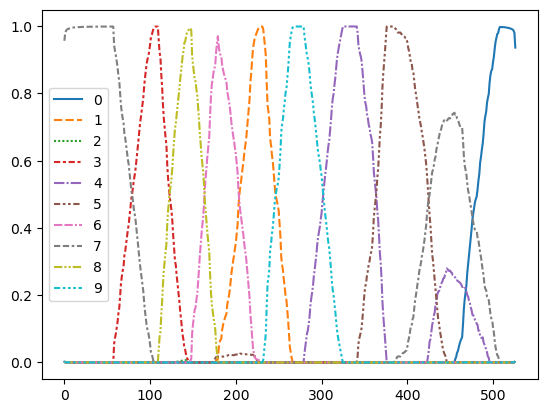

In [427]:
sns.lineplot(trajectory[:, trajectory.var(0) > 1e-7])

In [210]:
import seaborn as sns

In [141]:
def get_top_words(cv, lda, n_words=10):
    topic_words = {}
    vocab = cv.get_feature_names_out()
    for topic, component in enumerate(lda.components_):
        word_ix = np.argsort(component)[::-1][:n_words]
        topic_words[topic] = [vocab[i] for i in word_ix]
    return topic_words

In [143]:
for topic, words in get_top_words(atlep1.fit_cv, atlep1.fit_lda).items():
    print(f'{topic}: {", ".join(words)}')

0: van, reporter, apartment, indoor, tv, suspect, earn, news, wound, woman
1: zoo, fine, feel, feign, fifteen, fight, finally, find, finger, fault
2: zoo, fine, feel, feign, fifteen, fight, finally, find, finger, fault
3: zoo, fine, feel, feign, fifteen, fight, finally, find, finger, fault
4: van, earn, mother, door, mom, wine, indoor, walk, bottle, drink
5: zoo, fine, feel, feign, fifteen, fight, finally, find, finger, fault
6: zoo, fine, feel, feign, fifteen, fight, finally, find, finger, fault
7: zoo, fine, feel, feign, fifteen, fight, finally, find, finger, fault
8: zoo, fine, feel, feign, fifteen, fight, finally, find, finger, fault
9: zoo, fine, feel, feign, fifteen, fight, finally, find, finger, fault
10: earn, swiff, parent, house, alfred_paper_boy, dad, outdoor, ask, airport, indoor
11: zoo, fine, feel, feign, fifteen, fight, finally, find, finger, fault
12: zoo, fine, feel, feign, fifteen, fight, finally, find, finger, fault
13: zoo, fine, feel, feign, fifteen, fight, finally

In [14]:
def find_in_recalls(target, preprocess=False, show_subids=False, pad=50):
    n_matches = 0
    
    if show_subids:
        episode_subids_substrs = {}
        for episode in ('atlep1', 'atlep2', 'arrdev'):
            subids_substrs = {}
            for p in participants:
                if (
                    (episode == 'atlep2' and p.condition == 'B') or 
                    (episode == 'arrdev' and p.condition == 'A')
                ):
                    continue
                participant_substrs = []
                p_transcript = p.transcripts[episode]
                if preprocess:
                    p_transcript = preprocess_text(p_transcript)
                for match in re.finditer(target, p_transcript, flags=re.IGNORECASE):
                    participant_substrs.append(p_transcript[match.start()-pad:match.start()+pad])
                
                if len(participant_substrs) > 0:
                    subids_substrs[p.subid] = participant_substrs
                    n_matches += len(participant_substrs)
            
            if len(subids_substrs) > 0:
                episode_subids_substrs[episode] = subids_substrs
        
        print(f'{n_matches} matches:\n')
        for episode, subids_substrs in episode_subids_substrs.items():
            print(f'{"="*(2*pad+8)}\n{episode}')
            for subid, substrs in subids_substrs.items():
                print(f'    {subid}')
                for substr in substrs:
                    print(f'        {substr}')

    else:
        all_recalls = (
            ' '.join([p.transcripts['atlep1'] for p in participants])
            + ' '.join([p.transcripts['atlep2'] for p in participants if p.condition == 'A'])
            + ' '.join([p.transcripts['arrdev'] for p in participants if p.condition == 'B'])
        )
        if preprocess:
            all_recalls = preprocess_text(all_recalls)
        substrs = []
        for match in re.finditer(target, all_recalls, flags=re.IGNORECASE):
            n_matches += 1
            substrs.append(all_recalls[match.start()-pad:match.start()+pad])

        print(f'{n_matches} matches:\n')
        for substr in substrs:        
            print(substr)

In [435]:
# find_in_recalls(r"\bmark\b", preprocess=False, show_subids=True)

In [172]:
# all_annots = (
#     pd.concat((atlep1.annotations, atlep2.annotations, arrdev.annotations), ignore_index=True)
#     .loc[:, 'Narrative details (external events)':'Setting']
#     .apply(lambda row: '. '.join(row.dropna()), axis=1)
# )

In [174]:
# target = r"fine"

# joined_annots = ' '.join(all_annots)
# # joined_annots = ' '.join(joined)
# # joined_annots = ' '.join(joined.str.replace(r"(?<=\W)'|(?<!s)(?<!in)'(?=\W)", '', regex=True))
# # joined_annots = joined_annot

# pad = 50

# substrs = []
# n_matches = 0

# for match in re.finditer(target, joined_annots, flags=re.IGNORECASE):
#     n_matches += 1
#     substrs.append(joined_annots[match.start()-pad:match.start()+pad])
    
# print(f'{n_matches} matches:\n')
# for substr in substrs:
#     print(substr)

3 matches:

r there by the, when you first walked in. "No I'm fine with talking right here.". Darius, Alfred Pap
outdoor. radio station parking lot Dave says it's fine that Earn cannot pay to have Paper Boy's song
unit.. Interviewer. yes. in Arizona in one of our finest estates.. Interviewer. indoor. Sitwell hous


/mnt/data/raw/transcriptions/MD-022719-A-01/debugYwV6a:debugs5Yuo/debugYwV6a:debugs5Yuo-delayed.txt
